# Constructing a hycom1 vertical coordinate spec for CESM3
- Author: Ian Grooms (ian.grooms@colorado.edu)
- Minor modifications by Jiang Zhu (jiangzhu@ucar.edu)
  - Improved computational efficiency.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import time
import xarray as xr
from collections import OrderedDict
from netCDF4 import Dataset
from numba import njit
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import PchipInterpolator

## Preliminaries

Set the reference pressure to 2000 dbar

In [2]:
p_ref = 2000

In [3]:
def dens_wright_full(T, S, z):
    """
    Equation of state for sea water given by Wright, 1997, J. Atmos. Ocean. Tech., 14, 735-740.
    Units: T[degC],S[PSU],z[m]   (was p[Pa])
    Returns density [kg m-3]
    """

    p = 9.8 * 1020.41 * z

    a0 = 7.133718e-4; a1 = 2.72467e-7; a2 = -1.646582e-7
    b0 = 5.61377e8;   b1 = 3.600337e6; b2 = -3.727194e4; b3 = 1.660557e2;  b4 = 6.844158e5;  b5 = -8.389457e3
    c0 = 1.609893e5;  c1 = 8.427815e2; c2 = -6.931554;   c3 = 3.869318e-2; c4 = -1.664201e2; c5 = -2.765195

    al0 = a0 + a1 * T + a2 * S
    p0 = b0 + b4 * S + T * (b1 + T * (b2 + b3 * T) + b5 * S)
    l = c0 + c4 * S + T * (c1 + T * (c2 + c3 * T) + c5 * S)

    dens = (p + p0) / (l + al0*(p+p0))
    if isinstance(T, xr.DataArray):
        return dens.assign_attrs(units=r"kg m$^{-3}$", standard_name="Density-like")
    return dens

Load WOA data

Deepest point [m] = 5500.0


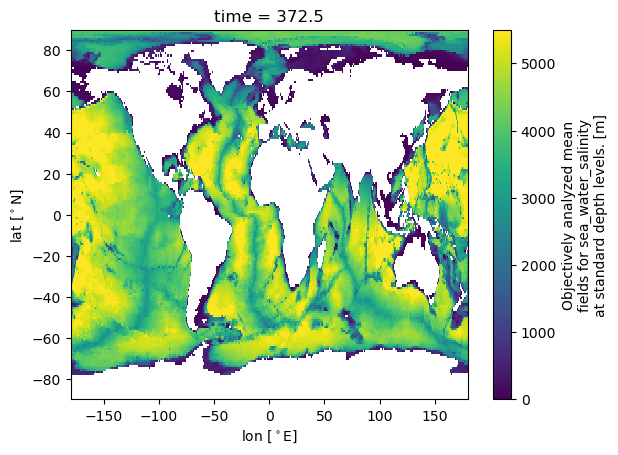

In [4]:
Re = 6370e3      #   [m]
deg2rad = np.pi / 180

ds = xr.open_dataset('/glade/campaign/cgd/oce/datasets/obs/woa18/woa18_decav_merged_monthly_deep_01.nc')
ds['depth'] = ds.depth.assign_attrs(units='m')
ds['lat'] = ds.lat.assign_attrs(units=r'$^\circ$N')
ds['lon'] = ds.lon.assign_attrs(units=r'$^\circ$E')
ds['lateral'] = ( 0 * ds.lat * ds.lon ).where( ds.s_an.isel(depth=0) >= 0 ) # Convenience for broadcasting
ds['area'] = ( Re**2 * deg2rad * ( np.sin( deg2rad * ( ds.lat + 0.5 ) ) - np.sin( deg2rad * ( ds.lat - 0.5 ) ) ) + ds.lateral ).assign_attrs(units='m2',standard_name="Area")
ds['topo'] = ( ds.depth + 0 * ds.s_an ).max(dim='depth').assign_attrs(units='m',standard_name="Bathymetry")
ds.topo.isel(time=0).plot()
print('Deepest point [m] =', ds.topo.max().data)

Define basin masks. Code originally from Alistair Adcroft, with adaptations.

In [6]:
def genBasinMasks(depth, contiguous=False, verbose=True, xda=True):
  """
  Returns masking for different regions.

  Parameters
  ----------
  x : 2D array
    Longitude

  y : 2D array
    Latitude

  depth : 2D array
    Ocean depth. Masked values must be set to zero.

  verbose : boolean, optional
    If True, print some stuff. Default is false.

  xda : boolean, optional
    If True, returns an xarray Dataset. Default is false.

  Returns
  -------
  """
  rmask_od = OrderedDict()
  rmask_od['Global'] = xr.where(depth > 0, 1.0, 0.0)

  x = depth.lon.values
  y = depth.lat.values
  x, y = np.meshgrid(x, y)
  # y, x = np.meshgrid(y, x)
  depth = np.nan_to_num(depth.values)

  if verbose: print('Generating global wet mask...')
  if contiguous:
    wet = ice9(x, y, depth, (0,-35)) # All ocean points seeded from South Atlantic
  else:
    wet = 0 * depth
    wet[depth>0] = 1
  if verbose: print('done.')

  code = 0*wet

  if verbose: print('Finding Cape of Good Hope ...')
  tmp = 1 - wet; tmp[x<-30] = 0
  tmp = ice9(x, y, tmp, (20,-30.))
  yCGH = (tmp*y).min()
  if verbose: print('done.', yCGH)

  if verbose: print('Finding Melbourne ...')
  if x.min()<-180:
    tmp = 1 - wet; tmp[x>-180] = 0
    tmp = ice9(x, y, tmp, (-220,-25.))
  else:
    tmp = 1 - wet
    tmp = ice9(x, y, tmp, (360-220,-25.))
  yMel = (tmp*y).min()
  if verbose: print('done.', yMel)

  if verbose: print('Processing Persian Gulf ...')
  tmp = wet*( 1-southOf(x, y, (55.,23.), (56.5,27.)) )
  tmp = ice9(x, y, tmp, (53.,25.))
  code[tmp>0] = 11
  rmask_od['PersianGulf'] = xr.where(code == 11, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Red Sea ...')
  tmp = wet*( 1-southOf(x, y, (40.,11.), (45.,13.)) )
  tmp = ice9(x, y, tmp, (40.,18.))
  code[tmp>0] = 10
  rmask_od['RedSea'] = xr.where(code == 10, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Black Sea ...')
  tmp = wet*( 1-southOf(x, y, (26.,42.), (32.,40.)) )
  tmp = ice9(x, y, tmp, (32.,43.))
  code[tmp>0] = 7
  rmask_od['BlackSea'] = xr.where(code == 7, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Mediterranean ...')
  tmp = wet*( southOf(x, y, (-5.7,35.5), (-5.7,36.5)) )
  tmp = ice9(x, y, tmp, (4.,38.))
  code[tmp>0] = 6
  rmask_od['MedSea'] = xr.where(code == 6, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Baltic ...')
  tmp = wet*( southOf(x, y, (14,54.), (14,63.)) )# wet*( southOf(x, y, (8.6,56.), (8.6,60.)) )
  tmp = ice9(x, y, tmp, (20.,56.)) # ice9(x, y, tmp, (10.,58.))
  code[tmp>0] = 9
  rmask_od['BalticSea'] = xr.where(code == 9, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Hudson Bay ...')
  tmp = wet*(
             ( 1-(1-southOf(x, y, (-95.,66.), (-83.5,67.5)))
                *(1-southOf(x, y, (-83.5,67.5), (-84.,71.)))
             )*( 1-southOf(x, y, (-70.,58.), (-70.,65.)) ) )
  tmp = ice9(x, y, tmp, (-85.,60.))
  code[tmp>0] = 8
  rmask_od['HudsonBay'] = xr.where(code == 8, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Arctic ...')
  tmp = wet*(
            (1-southOf(x, y, (-171.,66.), (-166.,65.5))) * (1-southOf(x, y, (-64.,66.4), (-50.,68.5))) # Lab Sea
       +    southOf(x, y, (-50.,0.), (-50.,90.)) * (1- southOf(x, y, (0.,65.5), (360.,65.5))  ) # Denmark Strait
       +    southOf(x, y, (-18.,0.), (-18.,65.)) * (1- southOf(x, y, (0.,64.9), (360.,64.9))  ) # Iceland-Sweden
       +    southOf(x, y, (20.,0.), (20.,90.)) # Barents Sea
       +    (1-southOf(x, y, (-280.,55.), (-200.,65.)))
            )
  tmp = ice9(x, y, tmp, (0.,85.))
  code[tmp>0] = 4
  rmask_od['Arctic'] = xr.where(code == 4, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Atlantic ...')
  tmp = wet*(1-southOf(x, y, (0.,yCGH), (360.,yCGH)))
  tmp = ice9(x, y, tmp, (-20.,0.))
  code[tmp>0] = 2
  rmask_od['AtlanticOcean'] = xr.where(code == 2, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Pacific ...')
  tmp = wet*( (1-southOf(x, y, (0.,yMel), (360.,yMel)))
             -southOf(x, y, (360-257,1), (360-257,0))*southOf(x, y, (0,3), (1,3))*southOf(x, y, (0,0), (0,1))
             -southOf(x, y, (360-254.25,1), (360-254.25,0))*southOf(x, y, (0,-5), (1,-5))*southOf(x, y, (0,0), (0,1))
             -southOf(x, y, (360-243.7,1), (360-243.7,0))*southOf(x, y, (0,-8.4), (1,-8.4))*southOf(x, y, (0,0), (0,1))
             -southOf(x, y, (360-234.5,1), (360-234.5,0))*southOf(x, y, (0,-8.9), (1,-8.9))*southOf(x, y, (0,0), (0,1))
            )
  tmp = ice9(x, y, tmp, (150.,0.)) # ice9(x, y, tmp, (-150.,0.))
  code[tmp>0] = 3
  rmask_od['PacificOcean'] = xr.where(code == 3, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Indian ...')
  tmp = wet*(1-southOf(x, y, (0.,yCGH), (360.,yCGH)))
  tmp = ice9(x, y, tmp, (55.,0.))
  code[tmp>0] = 5
  rmask_od['IndianOcean'] = xr.where(code == 5, 1.0, 0.0)
  wet = wet - tmp # Removed named points

  if verbose: print('Processing Southern Ocean ...')
  tmp = ice9(x, y, wet, (0.,-55.))
  code[tmp>0] = 1
  rmask_od['SouthernOcean'] = xr.where(code == 1, 1.0, 0.0)
  wet = wet - tmp # Removed named points
    
  #if verbose: print('Remapping Persian Gulf points to the Indian Ocean for OMIP/CMIP6 ...')
  #code[code==11] = 5

  # code[wet>0] = -9
  # (j,i) = np.unravel_index( wet.argmax(), x.shape)
  # if j:
  #   if verbose: print('There are leftover points unassigned to a basin code')
  #   while j:
  #     print(x[j,i],y[j,i],[j,i])
  #     wet[j,i]=0
  #     (j,i) = np.unravel_index( wet.argmax(), x.shape)
  # else:
  #   if verbose: print('All points assigned a basin code')

  ################### IMPORTANT ############################
  # points from following regions are not "removed" from wet
  code1 = code.copy()
  wet = ice9(x, y, depth, (0,-35)) # All ocean points seeded from South Atlantic
  if verbose: print('Processing Labrador Sea ...')
  tmp = wet*((southOf(x, y, (-65.,66.), (-45,66.)))
    *(southOf(x, y, (-65.,52.), (-65.,66.)))
    *(1-southOf(x, y, (-45.,52.), (-45,66.)))
    *(1-southOf(x, y, (-65.,52.), (-45,52.))))

  tmp = ice9(x, y, tmp, (-50.,55.))
  code1[tmp>0] = 12
  rmask_od['LabSea'] = xr.where(code1 == 12, 1.0, 0.0)

  wet1 = ice9(x, y, depth, (0,-35)) # All ocean points seeded from South Atlantic
  if verbose: print('Processing Baffin Bay ...')
  tmp = wet1*((southOf(x, y, (-94.,80.), (-50.,80.)))
    *(southOf(x, y, (-94.,66.), (-94.,80.)))
    *(1-southOf(x, y, (-94.,66.), (-50,66.)))
    *(1-southOf(x, y, (-50.,66.), (-50.,80.))))

  tmp = ice9(x, y, tmp, (-70.,73.))
  code1[tmp>0] = 13
  # remove Hudson Bay
  code1[rmask_od['HudsonBay']>0] = 0.
  rmask_od['BaffinBay'] = xr.where(code1 == 13, 1.0, 0.0)

  wet1 = ice9(x, y, depth, (0,-35)) # All ocean points seeded from South Atlantic
  if verbose: print('Processing Gulf of Mexico ...')
  tmp = wet*( (1-southOf(x, y, (360.-98.,18.), (360.-78.,18.)))
                *southOf(x, y, (360.-98.,32.), (360.-78.,32.))
             *(1-southOf(x, y, (-78.,0.), (-78.,1.)))
             # -southOf(x, y, (360-254.25,1), (360-254.25,0))*southOf(x, y, (0,-5), (1,-5))*southOf(x, y, (0,0), (0,1))
             # -southOf(x, y, (360-243.7,1), (360-243.7,0))*southOf(x, y, (0,-8.4), (1,-8.4))*southOf(x, y, (0,0), (0,1))
             # -southOf(x, y, (360-234.5,1), (360-234.5,0))*southOf(x, y, (0,-8.9), (1,-8.9))*southOf(x, y, (0,0), (0,1))
            )
  tmp = ice9(x, y, tmp, (-90.,25.))
  code1[tmp>0] = 14
  rmask_od['GoM'] = xr.where(code1 == 14, 1.0, 0.0)

  if verbose: print('Processing Caspian ...')
  tmp = xr.where(depth > 0, 1.0, 0.0)
  tmp = ice9(x, y, tmp, (51., 39.))
  code[tmp>0] = 15
  rmask_od['CaspianSea'] = xr.where(code == 15, 1.0, 0.0)

  with Dataset("mapmsk_Celebes.nc", "r", format="NETCDF4") as rootgrp:
      tmp = np.array(rootgrp["Celebes"][:])
  code[tmp>0] = 16
  rmask_od['Celebes'] = xr.where(code == 16, 1.0, 0.0)

  with Dataset("mapmsk_Japan.nc", "r", format="NETCDF4") as rootgrp:
      tmp = np.array(rootgrp["Japan"][:])
  code[tmp>0] = 17
  rmask_od['Japan'] = xr.where(code == 17, 1.0, 0.0)

  with Dataset("mapmsk_Sulu.nc", "r", format="NETCDF4") as rootgrp:
      tmp = np.array(rootgrp["Sulu"][:])
  code[tmp>0] = 18
  rmask_od['Sulu'] = xr.where(code == 18, 1.0, 0.0)

  wet1 = ice9(x, y, depth, (0,-35)) # All ocean points seeded from South Atlantic
  if verbose: print('Processing CARIB12 ...')
  tmp = wet*( (1-southOf(x, y, (360.-98.5,-6.), (360.-35.5,-6.)))
                *southOf(x, y, (360.-98.5,32.), (360.-35.5,32.))
             *(1-southOf(x, y, (-35.5,0.), (-35.5,1.)))
            )
  tmp = ice9(x, y, tmp, (-90.,25.))
  code1[tmp>0] = 19
  rmask_od['CARIB12'] = xr.where(code1 == 19, 1.0, 0.0)
    
  if verbose:
    print("""
  Basin codes:
  -----------------------------------------------------------
  (0) Global              (9) Pacific Ocean
  (1) Persian Gulf        (10) Indian Ocean
  (2) Red Sea             (11) Southern Ocean
  (3) Black Sea           (12) Labrador Sea
  (4) Mediterranean       (11) Persian Gulf
  (5) Baltic              (13) Baffin Bay
  (6) Hudson Bay          (14) Gulf of Mexico
  (7) Arctic & GIN Seas   (15) Caspian Sea
  (8) Atlantic            (16) Celebes Sea
  (17) Japan/East Sea     (18) Sulu Sea
  (19) CARIB12
  Important: basin codes overlap. Code 12 and higher are only loaded if xda=True.

    """)

  rmask = xr.DataArray(np.zeros((len(rmask_od), depth.shape[0], depth.shape[1])),
                         dims=('region', 'yh', 'xh'),
                         coords={'region':list(rmask_od.keys())})

  for i, rmask_field in enumerate(rmask_od.values()):
        rmask.values[i,:,:] = rmask_field

  if xda:
    return rmask
  else:
    return code

def ice9it(i, j, depth, minD=0.):
  """
  Recursive implementation of "ice 9".
  Returns 1 where depth>minD and is connected to depth[j,i], 0 otherwise.
  """
  wetMask = 0*depth

  (nj,ni) = wetMask.shape
  stack = set()
  stack.add( (j,i) )
  while stack:
    (j,i) = stack.pop()
    if wetMask[j,i] or depth[j,i] <= minD: continue
    wetMask[j,i] = 1

    if i>0: stack.add( (j,i-1) )
    else: stack.add( (j,ni-1) ) # Periodic beyond i=0

    if i<ni-1: stack.add( (j,i+1) )
    else: stack.add( (j,0) ) # Periodic beyond i=ni-1

    if j>0: stack.add((j-1,i))

    if j<nj-1: stack.add( (j+1,i) )
    else: stack.add( (j,ni-1-i) ) # Tri-polar fold beyond j=nj-1

  return wetMask

def nearestJI(x, y, x0, y0):
  """
  Find (j,i) of cell with center nearest to (x0,y0).
  """
  return np.unravel_index( ((x-x0)**2 + (y-y0)**2).argmin() , x.shape)

def ice9(x, y, depth, xy0):
  ji = nearestJI(x, y, xy0[0], xy0[1])
  return ice9it(ji[1], ji[0], depth)

def southOf(x, y, xy0, xy1):
  """
  Returns 1 for point south/east of the line that passes through xy0-xy1, 0 otherwise.
  """
  x0 = xy0[0]; y0 = xy0[1]; x1 = xy1[0]; y1 = xy1[1]
  dx = x1 - x0; dy = y1 - y0
  Y = (x-x0)*dy - (y-y0)*dx
  Y[Y>=0] = 1; Y[Y<=0] = 0
  return Y

codes = genBasinMasks(ds.topo.isel(time=0))

Generating global wet mask...
done.
Finding Cape of Good Hope ...
done. -34.5
Finding Melbourne ...
done. -39.5
Processing Persian Gulf ...
Processing Red Sea ...
Processing Black Sea ...
Processing Mediterranean ...
Processing Baltic ...
Processing Hudson Bay ...
Processing Arctic ...
Processing Atlantic ...
Processing Pacific ...
Processing Indian ...
Processing Southern Ocean ...
Processing Labrador Sea ...
Processing Baffin Bay ...
Processing Gulf of Mexico ...
Processing Caspian ...
Processing CARIB12 ...

  Basin codes:
  -----------------------------------------------------------
  (0) Global              (9) Pacific Ocean
  (1) Persian Gulf        (10) Indian Ocean
  (2) Red Sea             (11) Southern Ocean
  (3) Black Sea           (12) Labrador Sea
  (4) Mediterranean       (11) Persian Gulf
  (5) Baltic              (13) Baffin Bay
  (6) Hudson Bay          (14) Gulf of Mexico
  (7) Arctic & GIN Seas   (15) Caspian Sea
  (8) Atlantic            (16) Celebes Sea
  (17) Jap

In [7]:
@njit
def remove_instabilities(s2):
    S2 = s2.copy()
    if np.isnan(S2[0]):
        return S2
    running_max = S2[0]
    for k in range(1, S2.shape[0]):
        if np.isnan(S2[k]):
            break
        if S2[k] < running_max:
            S2[k] = running_max
        else:
            running_max = S2[k]
    return S2

## Set min and max z-star levels
The minimum z-star interface depths correspond to 
- Four 2.5 m thick layers
- Two 3 m layers and one 4 m layer
- Layers with thicknesses starting at 5 m and increasing gradually at first, then rapidly

In [8]:
max_depth = 6000  # I got this manually from the MOM6 geometry file

z_min_new = np.zeros(76)
z_min_new[:5] = 2.5*np.arange(5)  # Must have 4x 2.5m layers
z_min_new[5] = 13
z_min_new[6] = 16
z_min_new[7] = 20
z_min_new[8:] = z_min_new[7] + 5*np.arange(1,69) + (max_depth - z_min_new[7] - 5*68)*(np.linspace(0,1,69)[1:]**9)

print(z_min_new[-4:]-z_min_new[-5:-1])

[494.39851794 558.48767521 629.80381033 709.03451811]


The cell below sets `z_max`, which is the max depth of an interface. Using this option helps to avoid having one thick layer at the bottom followed by a bunch of vanished layers (thicknesses equal to `dz_min`, which is 0.001 m). The cell below sets `z_max` so that the levels can't be deeper than an equispaced z-star grid would be. In some regions you'll get a sequence of 80 m layers at the bottom rather than one thick one and several vanished ones. 

In [9]:
z_max_new = np.rint(np.linspace(0, max_depth, 76))
z_max_new[-1] = max_depth

## Compute vertical grid-distribution functions at each horizontal location

We are eventually going to compute grid-density functions for each column and then combine them. If we treated all the columns equally, then the shallow columns would try to fit 75 layers, which would tend to produce a shallow grid. To avoid this, when we combine the columns we will weight them using the depth. To be precise, we will weight the columns based on the maximum number of non-vanished layers that could fit into that column. So shallow columns will be down-weighted compared to deep columns. We will also ignore columns that are 20 m deep or shallower, since we will force the grid to be geopotential in those columns anyways.

The cell below also removes several regions: The Black Sea, the Baltic, Hudson Bay, the Arctic Ocean, Baffin Bay, and the Caspian Sea. We expect these regions to have geopotential coordinates anyways, so they shouldn't be used to set the isopycnal targets.

20.0


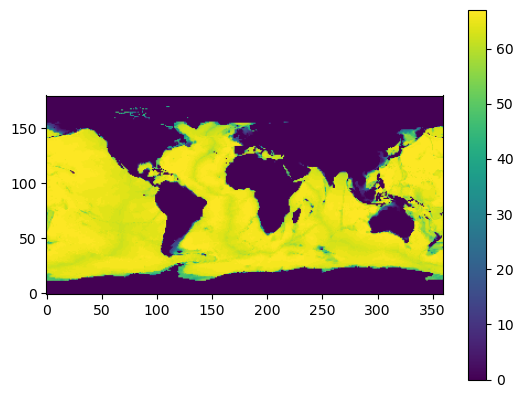

In [11]:
num_skip = 8  # If the depth does not allow at least num_skip z_min interfaces, then skip that column
              # num_skip=8 means at least 20 m depth
print(z_min_new[num_skip-1])
weights = np.zeros((180,360))
for i in range(180):
    for j in range(360):
        if ((z_min_new < ds.topo.data[0,i,j]).sum() <= num_skip):
            weights[i,j] = 0
        else:
            weights[i,j] = (z_min_new < ds.topo.data[0,i,j]).sum() - num_skip

weights[codes[3].data.astype(bool)] = 0.  # Black Sea
weights[codes[5].data.astype(bool)] = 0.  # Baltic
weights[codes[6].data.astype(bool)] = 0.  # Hudson Bay
weights[codes[7].data.astype(bool)] = 0.  # Arctic
weights[codes[13].data.astype(bool)] = 0.  # Baffin
weights[codes[15].data.astype(bool)] = 0.  # Caspian
plt.imshow(weights)
plt.gca().invert_yaxis()
plt.colorbar()

### Get $\rho_2$ on an equispaced 5 m grid
The cell below interpolates WOA T and S to an equispaced 5 m grid and then evaluate $rho_2$ on that grid. (Note that although the variable name is `sigma2` is actually $\rho_2$, not $\sigma_2 = \rho_2 - 1000$). Interpolation uses a shape-preserving cubic spline. It is more accurate to interpolate T and S and then evaluate the EOS than to evaluate the EOS on the WOA grid and then interpolate to the equispaced grid. This is both slow and high-memory.

In [12]:
nz = 5500 // 5 + 1  # WOA max depth / 5 m resolution
z_grid = np.linspace(0,5500,num=nz)  # 5500 here is the WOA max depth

depth = ds.depth.data
depth[0] = 0.0  # The WOA data has the first 'depth' at 0. 
                # The data used here is at the center of the top cell, 5 m. 
                # This leads to problems below, so we re-interpret the top cell data as being at the top surface.
theta = ds.theta0.data
salt  = ds.s_an.data

# first_nan[tt,jj,ii] = index of first NaN; set to len(depth) if no NaNs
first_nan = np.where(np.isnan(theta).any(axis=1),
                     np.argmax(np.isnan(theta), axis=1),
                     theta.shape[1])

sigma2 = np.full((12, nz, 180, 360), np.nan)
for tt in range(12):
    # skip land and single-level columns
    good = np.argwhere(first_nan[tt] > 1)
    for jj, ii in good:
        n = first_nan[tt, jj, ii]
        Ti = PchipInterpolator(depth[:n], theta[tt, :n, jj, ii], extrapolate=False)(z_grid)
        Si = PchipInterpolator(depth[:n], salt [tt, :n, jj, ii], extrapolate=False)(z_grid)
        sigma2[tt, :, jj, ii] = remove_instabilities_numba(dens_wright_full(Ti, Si, p_ref))
Ti = None
Si = None

The cell below evaluates the grid-distribution function

$$S_k = \sum_{i=1}^kh_i(\sigma_i-\sigma_{i-1})$$

where $h_k$ is 5 m. It then considers this to be a function of potential density, and interpolates the values to an equispaced grid in potential density, with spacing 0.01 between the floor and ceil.

We do not include values of density from depths shallower than 20 m to compute the per-column grid-distribution functions. The results should therefore not be used to compute target interface densities for interfaces 0 through 7.

If the grid-density function for a column wants to have a higher density of grid cells than is allowed by the z-star grid, then we limit the computed grid-density function to the value associated with the z-star grid.

In [ ]:
# Find the range of potential density values that we will interpolate over
sigma2_floor = np.floor(np.nanmin(sigma2))
sigma2_ceil  = np.ceil(np.nanmax(sigma2))
print(sigma2_floor,sigma2_ceil)
# dskip = 5 means that the first density difference is between 20 and 25 m.
# It should therefore be used to find all but the first 8 interfaces (i.e. use it to find targets [8:] in Python)
dskip = 5
nk = 76
sigma2_min = np.floor(np.nanmin(sigma2[:,dskip-1:,:,:]))
sigma2_max = np.ceil(np.nanmax(sigma2[:,dskip-1:,:,:]))
num_s2 = (1 + (sigma2_max-sigma2_min)*100).astype(int)  # Might help to increase resolution here, but it would cost memory
s2_grid = np.linspace(sigma2_min, sigma2_max, num=num_s2)
S_interp = np.full((12, num_s2, 180, 360), np.nan)

S_lim = np.zeros(num_s2)
s_min = np.zeros((12,nk,180,360))

for tt in range(12):
    ck = np.zeros_like(Sk)
    for k in range(dskip+1,nz-1):
        ck[k,:,:] = np.sqrt(np.maximum(0,(sigma2[tt,k,:,:]-sigma2[tt,k-1,:,:])))
    Sk = scipy.integrate.cumulative_trapezoid(ck, axis=0, initial=0)
    Sk[0:dskip+1,:,:] = 0.

    ck = None
    nskip = 0
    for jj in range(180):
        for ii in range(360):
            if(weights[jj,ii] > 0.):
                d = 1100
                if np.isnan(sigma2[tt,:,jj,ii]).any():
                    d = np.where(np.isnan(sigma2[tt,:,jj,ii]))[0][0] -1
                if d > dskip:
                    try:
                        if (np.diff(sigma2[tt,dskip-1:d,jj,ii]) == 0).any():
                            ind_unique = dskip - 1 + np.unique(sigma2[tt,dskip-1:d,jj,ii], return_index=True)[1]
                            S_interp[tt,:,jj,ii] = PchipInterpolator(sigma2[tt,ind_unique,jj,ii],
                                                                     Sk[ind_unique,jj,ii]/np.nanmax(Sk[ind_unique,jj,ii]),extrapolate=False)(s2_grid)
                        else:
                            S_interp[tt,:,jj,ii] = PchipInterpolator(sigma2[tt,dskip-1:d,jj,ii],
                                                                    Sk[dskip-1:d,jj,ii]/np.nanmax(Sk[dskip-1:d,jj,ii]),extrapolate=False)(s2_grid)
                        if (S_interp[tt,:,jj,ii] >= 0 ).any():
                            S_interp[tt,0:np.where(S_interp[tt,:,jj,ii] >= 0 )[0][0],jj,ii] = 0
                        if np.where(S_interp[tt,:,jj,ii] <= 1)[0].shape[0] > 0:
                            S_interp[tt,(np.where(S_interp[tt,:,jj,ii] <= 1)[0][-1]+1):,jj,ii] = 1
                    except:
                        nskip += 1
                # The line below applies depth weighting.
                S_interp[tt,:,jj,ii] *= weights[jj,ii]
                # The lines below apply limiting based on the z* grid.
                nan_indices = np.where(np.isnan(theta[tt,:,jj,ii]))[0]
                if nan_indices.shape[0] > 0:
                    first_nan = nan_indices[0]
                    if first_nan > 1:
                        s_min[tt,:,jj,ii] = dens_wright_full(PchipInterpolator(depth[:first_nan],theta[tt,:first_nan,jj,ii],extrapolate=False)(z_min_new[:]),
                                                             PchipInterpolator(depth[:first_nan],salt[tt,:first_nan,jj,ii],extrapolate=False)(z_min_new[:]), p_ref)
                else:
                    s_min[tt,:,jj,ii] = dens_wright_full(PchipInterpolator(depth[:],theta[tt,:,jj,ii],extrapolate=False)(z_min_new[:]),
                                                         PchipInterpolator(depth[:],salt[tt,:,jj,ii],extrapolate=False)(z_min_new[:]), p_ref)
                s_min[tt,:,jj,ii] = remove_instabilities(s_min[tt,:,jj,ii])
                d = nk
                if np.isnan(s_min[tt,:,jj,ii]).any():
                    d = np.where(np.isnan(s_min[tt,:,jj,ii]))[0][0] -1
                if d > num_skip:
                    try:
                        S_lim = PchipInterpolator(s_min[tt,dskip-1:d,jj,ii], np.linspace(0,1,d-dskip+1),extrapolate=False)(s2_grid)
                        if (S_lim >= 0).any():
                            S_lim[0:np.where(S_lim >= 0)[0][0]] = 0
                        if np.where(S_lim <= 1)[0].shape[0] > 0:
                            S_lim[(np.where(S_interp[tt,:,jj,ii] <= 1)[0][-1]+1):] = 1
                    except:
                        S_lim = 1
                S_interp[tt,:,jj,ii] = np.fmin(S_interp[tt,:,jj,ii],weights[jj,ii]*S_lim)
    print(tt, nskip)
Sk = None
s_min = None

1006.0 1040.0


/glade/derecho/scratch/igrooms/tmp/ipykernel_120022/1594919305.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Sk[k,:,:] = np.trapz(ck[:k+1,:,:],axis=0)
/glade/derecho/scratch/igrooms/tmp/ipykernel_120022/1594919305.py:43: RuntimeWarning: invalid value encountered in divide
  Sk[dskip-1:d,jj,ii]/np.nanmax(Sk[dskip-1:d,jj,ii]),extrapolate=False)(s2_grid)
/glade/derecho/scratch/igrooms/tmp/ipykernel_120022/1594919305.py:40: RuntimeWarning: invalid value encountered in divide
  Sk[ind_unique,jj,ii]/np.nanmax(Sk[ind_unique,jj,ii]),extrapolate=False)(s2_grid)


0 115
1 99
2 90
3 58


## Compute a single global grid-distribution function
Next we condense down to a single grid-distribution function $S(\sigma)$ that goes from 0 to 1.
First we compute the grid-density for each column.
Then, for each potential density in our equispaced grid of potential densities, we compute the 99.5th percentile of grid-densities across all columns, and take the result to be the single global value of grid-density at that value of potential density.
The resulting global grid-density function does not integrate to 1, so we normalize it so that it does.
The result is the global grid-distribution function.

In [ ]:
ps = np.zeros((12,num_s2 -1,180,360))
for jj in range(180):
    for ii in range(360):
        ps[:,:,jj,ii] = np.diff(S_interp[:,:,jj,ii],axis=1)/np.diff(s2_grid)[:]

S_interp = None

In [ ]:
# 99.5th percentile over x, y, and t
p95_ps = np.nanquantile(ps[:,:,:,:], 0.995, axis=(0,2,3))
p95_ss = np.concatenate((np.array([0]),np.cumsum(p95_ps)))
p95_ss = p95_ss/np.max(p95_ss)

## Compute target densities
Next we find target potential densities by inverting $S(\sigma)$ against a half-Chebyshev grid on 0,1.
Since the data was taken below 20 m, and it takes 8 interfaces to get to 20 m deep, we should not set the first 8 interfaces using this data. The first 8 interfaces are simply set to be linear from the min density in the WOA data to the 9th interface density. The last interface density is set to the densest value in the WOA data, rounded up to the nearest integer. All values are then truncated to 10 bit precision.

In [ ]:
def get_targets(x,y):
    # Input x should be s2_grid.
    # Input y is the grid distribution function evaluated at the s2 grid.
    # Output is the rho_pot_2 targets.
    ind_min = np.where(y == 0.)[0][-1]
    ind_max = np.where(y == 1.)[0][0]
    s2_targets = np.zeros(76)
    r_grid = 1 - np.cos(np.linspace(0,np.pi/2,num=68))
    s2_targets[8:-1] = np.interp(r_grid,y[ind_min:ind_max+1],x[ind_min:ind_max+1])[:-1]
    s2_targets[:8] = sigma2_floor + (s2_targets[8]-sigma2_floor)*np.arange(0,8)/8
    s2_targets[-1] = sigma2_ceil
    s2_targets = np.rint(s2_targets*1024)/1024
    assert(np.unique(s2_targets).shape[0] == s2_targets.shape[0])
    return s2_targets

In [ ]:
s2_targets_p95xy = get_targets(s2_grid, p95_ss)

## Set max thicknesses
At this point we want to set `dz_max`. The first four layers have 2.5 max thickness and then next three have max thicknesses 3, 3, and 4 m. This ensures that the top 20 m will be z-star. After that the max layer thicknesses are all 10 m down to a depth of 100 m. From 100 m down the max thicknesses increase in an ad hoc manner.

In [ ]:
dz_max_new = np.zeros(75)
dz_max_new[:4] = 2.5
dz_max_new[4:7] = np.array([3, 3, 4])
dz_max_new[7:23] = 10
dz_max_new[23:] = np.ceil((15/100 + (1 - 15/100)*np.linspace(0, 1.3, num=dz_max_new[23:].shape[0]))*z_min_new[23:-1])
dz_max_new = np.minimum(600, dz_max_new)
dz_max_new = np.maximum(np.diff(z_min_new),dz_max_new)

## Write the results to netCDF files

In [21]:
with Dataset("hybrid_75layer_zstar_2.50m-2026-04-28.nc", "w", format="NETCDF4") as rootgrp:
    rootgrp.author = 'Ian Grooms (ian.grooms@colorado.edu)'
    rootgrp.history= "Created " + time.ctime(time.time()) + " with cesm3_0_ocn_vgrid.ipynb"
    rootgrp.createDimension('layers', 75)
    rootgrp.createDimension('interfaces', 76)
    rootgrp.createVariable('sigma2','f8',('interfaces',),fill_value=np.nan)
    rootgrp["sigma2"].units = "kg/m^3"
    rootgrp["sigma2"].long_name = "Interface target potential density referenced to 2000db"
    rootgrp["sigma2"][:] = s2_targets_p95xy[:]
    rootgrp.createVariable('dz','f8',('layers',),fill_value=np.nan)
    rootgrp["dz"].units = "m"
    rootgrp["dz"].long_name = "z* coordinate level thicknesses"
    rootgrp["dz"][:] = np.diff(z_min_new)

In [103]:
with Dataset("dz_max.nc", "r+", format="NETCDF4") as rootgrp:
    rootgrp.history= "Created " + time.ctime(time.time()) + " with cesm3_0_ocn_vgrid.ipynb"
    rootgrp.description = 'Max layer thicknesses'
    rootgrp["dz"].units = "m"
    rootgrp["dz"][:] = dz_max_new[:]

In [104]:
with Dataset("lev.nc", "w", format="NETCDF4") as rootgrp:
    rootgrp.history= "Created " + time.ctime(time.time()) + " with cesm3_0_ocn_vgrid.ipynb"
    rootgrp.description = 'Max interface depths'
    rootgrp.author = 'Ian Grooms (ian.grooms@colorado.edu)'
    rootgrp.createDimension('z', 76)
    rootgrp.createVariable('Z','f8',('z',))
    rootgrp["Z"].units = "m"
    rootgrp["Z"][:] = z_max_new